In [1]:
# ============================================================
# 📦 Cell 1: 패키지 임포트 & 경로 설정
# ============================================================
# Gallery Expansion 파이프라인
#
# 목적:
#   선수당 프로필 사진 1장 → 총 N장으로 확장
#   (기존 임베딩을 평균 내는 게 아니라, 여러 임베딩을 유지)
#   유사도 검색 시 선수당 max similarity를 취함
#
# 출력 파일 (기존 파일과 별개):
#   data/embeddings/player_embeddings_gallery.json
#   data/player_images_gallery/{player_id}_{n}.jpg
#
# 전제 조건:
#   - kbo_crawling.ipynb 실행 완료
#     (data/embeddings/player_embeddings.json 존재)
#   - 네이버 이미지 검색 API 키 발급
#     https://developers.naver.com/ → 애플리케이션 등록
#     → 검색 API → 이미지 검색 사용 설정
# ============================================================

import os
import json
import time
import requests
import numpy as np
import cv2
from pathlib import Path
from io import BytesIO
from PIL import Image
from tqdm import tqdm
from insightface.app import FaceAnalysis

# 프로젝트 루트 (kbo-lookalike/) 기준 경로 설정
# VS Code Jupyter cwd는 프로젝트 루트 or python/ 둘 다 가능
_cwd = Path.cwd()
if (_cwd / "data" / "embeddings" / "player_embeddings.json").exists():
    PROJECT_ROOT = _cwd          # cwd가 이미 프로젝트 루트
elif (_cwd.parent / "data" / "embeddings" / "player_embeddings.json").exists():
    PROJECT_ROOT = _cwd.parent   # cwd가 python/ → 한 단계 위
else:
    raise FileNotFoundError("프로젝트 루트를 찾을 수 없습니다. data/embeddings/player_embeddings.json 경로를 확인하세요.")

DATA_DIR = PROJECT_ROOT / "data"

# 입력: 기존 파이프라인 결과물
ORIG_EMB_PATH  = DATA_DIR / "embeddings" / "player_embeddings.json"
ORIG_META_PATH = DATA_DIR / "metadata"   / "player_metadata.json"

# 출력: 갤러리 전용 디렉토리 (기존 파일과 분리)
GALLERY_IMG_DIR = DATA_DIR / "player_images_gallery"
GALLERY_EMB_PATH = DATA_DIR / "embeddings" / "player_embeddings_gallery.json"

GALLERY_IMG_DIR.mkdir(parents=True, exist_ok=True)

assert ORIG_EMB_PATH.exists(),  f"기존 임베딩 파일 없음: {ORIG_EMB_PATH}"
assert ORIG_META_PATH.exists(), f"기존 메타데이터 파일 없음: {ORIG_META_PATH}"

print("✅ 패키지 임포트 완료")
print(f"   프로젝트 루트: {PROJECT_ROOT}")
print(f"   입력:  {ORIG_EMB_PATH}")
print(f"   출력:  {GALLERY_EMB_PATH}")
print(f"   이미지: {GALLERY_IMG_DIR}")

✅ 패키지 임포트 완료
   프로젝트 루트: /Users/young/Desktop/Naco/Projects/kbo-lookalike
   입력:  /Users/young/Desktop/Naco/Projects/kbo-lookalike/data/embeddings/player_embeddings.json
   출력:  /Users/young/Desktop/Naco/Projects/kbo-lookalike/data/embeddings/player_embeddings_gallery.json
   이미지: /Users/young/Desktop/Naco/Projects/kbo-lookalike/data/player_images_gallery


In [2]:
# ============================================================
# ⚙️ Cell 2: 파라미터 설정
# ============================================================
# 네이버 이미지 검색 API 키
#   발급: https://developers.naver.com/ → 애플리케이션 등록
#   → API 설정 → 검색 (이미지) 추가
#   무료 한도: 25,000 calls/day (763명 검색에는 충분)
#
# TARGET_PER_PLAYER:
#   선수당 유지할 총 임베딩 수 (프로필 1개 포함)
#   예) 4 → 프로필 1 + 추가 최대 3장
#   모든 선수를 동일한 수로 맞춰야 유사도 편향이 없음
#
# SIMILARITY_THRESHOLD:
#   새 이미지가 기존 프로필 임베딩과 이 값 이상 유사해야 통과
#   동명이인 제거 + 헬멧 착용 등 가려진 사진 제거 역할
#   0.5가 기본값; 너무 엄격하면 올리고, 통과 수가 적으면 낮출 것
# ============================================================

NAVER_CLIENT_ID     = "ShWxCTuMy7_HUp9EW9uB"
NAVER_CLIENT_SECRET = "f44iRyeclo"

TARGET_PER_PLAYER   = 4      # 선수당 총 임베딩 수 (프로필 포함)
SIMILARITY_THRESHOLD = 0.50  # 기존 프로필 임베딩과의 최소 코사인 유사도
FACE_CONF_THRESHOLD  = 0.85  # SCRFD 얼굴 검출 confidence 최소값
MIN_FACE_SIZE        = 80    # 얼굴 bbox 최소 너비/높이 (px)
SEARCH_PER_PLAYER    = 20    # 선수당 네이버 이미지 검색 결과 수
SLEEP_BETWEEN_REQ    = 0.3   # API 호출 간 딜레이 (초)

print("⚙️ 파라미터:")
print(f"   선수당 목표 임베딩 수:  {TARGET_PER_PLAYER}")
print(f"   유사도 임계값:          {SIMILARITY_THRESHOLD}")
print(f"   SCRFD confidence:      {FACE_CONF_THRESHOLD}")
print(f"   최소 얼굴 크기:         {MIN_FACE_SIZE}px")
print(f"   선수당 검색 이미지 수:  {SEARCH_PER_PLAYER}")
print()
print("⚠️  NAVER_CLIENT_ID / SECRET 입력 후 실행하세요")

⚙️ 파라미터:
   선수당 목표 임베딩 수:  4
   유사도 임계값:          0.5
   SCRFD confidence:      0.85
   최소 얼굴 크기:         80px
   선수당 검색 이미지 수:  20

⚠️  NAVER_CLIENT_ID / SECRET 입력 후 실행하세요


In [3]:
# ============================================================
# 📂 Cell 3: 기존 데이터 로드
# ============================================================

with open(ORIG_EMB_PATH, encoding="utf-8") as f:
    orig_emb_data = json.load(f)

with open(ORIG_META_PATH, encoding="utf-8") as f:
    meta_data = json.load(f)

# 기존 임베딩: {player_id: np.ndarray(512,)}
profile_embeddings = {
    pid: np.array(emb, dtype=np.float32)
    for pid, emb in orig_emb_data["players"].items()
}

# 메타데이터: {player_id: {name, team, ...}}
player_meta = {p["id"]: p for p in meta_data["players"]}

print(f"✅ 기존 임베딩 로드: {len(profile_embeddings)}명")
print(f"✅ 메타데이터 로드:  {len(player_meta)}명")
print(f"   임베딩 차원:      {len(next(iter(profile_embeddings.values())))}")

✅ 기존 임베딩 로드: 763명
✅ 메타데이터 로드:  763명
   임베딩 차원:      512


In [4]:
# ============================================================
# 🔍 Cell 4: 네이버 이미지 검색 & 다운로드 함수
# ============================================================

NAVER_API_URL = "https://openapi.naver.com/v1/search/image"
NAVER_HEADERS = {
    "X-Naver-Client-Id":     NAVER_CLIENT_ID,
    "X-Naver-Client-Secret": NAVER_CLIENT_SECRET,
}
DL_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/131.0.0.0 Safari/537.36"
    )
}


def search_naver_images(query: str, display: int = 20) -> list[dict]:
    """
    네이버 이미지 검색 API 호출.
    Returns: [{link, thumbnail, title, ...}, ...]
    """
    params = {
        "query":   query,
        "display": min(display, 100),
        "sort":    "sim",    # 관련도순
        "filter":  "large",  # 대용량 이미지 우선
    }
    resp = requests.get(NAVER_API_URL, headers=NAVER_HEADERS, params=params, timeout=10)
    resp.raise_for_status()
    return resp.json().get("items", [])


def download_image(url: str, save_path: Path) -> bool:
    """
    이미지 URL에서 다운로드 후 RGB JPEG로 저장.
    실패 시 False 반환 (예외를 발생시키지 않음).
    """
    try:
        resp = requests.get(url, headers=DL_HEADERS, timeout=8)
        if resp.status_code != 200 or len(resp.content) < 3000:
            return False
        img = Image.open(BytesIO(resp.content)).convert("RGB")
        if img.width < MIN_FACE_SIZE or img.height < MIN_FACE_SIZE:
            return False
        img.save(save_path, "JPEG", quality=92)
        return True
    except Exception:
        return False


print("✅ 네이버 API 함수 정의 완료")

# --- API 키 유효성 테스트 ---
try:
    test_results = search_naver_images("강백호 한화 이글스 야구", display=1)
    print(f"✅ API 키 유효 — 테스트 결과 {len(test_results)}건")
except Exception as e:
    print(f"❌ API 호출 실패: {e}")
    print("   NAVER_CLIENT_ID / NAVER_CLIENT_SECRET 을 확인하세요")

✅ 네이버 API 함수 정의 완료
✅ API 키 유효 — 테스트 결과 1건


In [8]:
# ============================================================
# 🧠 Cell 5: InsightFace 모델 로드
# ============================================================

_models_dir = PROJECT_ROOT / "python" / "models"
if not _models_dir.exists():
    _models_dir = PROJECT_ROOT / "models"

app = FaceAnalysis(
    name="buffalo_sc",
    root=str(_models_dir),
    providers=["CPUExecutionProvider"],
)
app.prepare(ctx_id=0, det_size=(640, 640))

print("✅ InsightFace 로드 완료 (buffalo_sc)")

MAX_IMG_DIM = 2000
_CRASH_LOG = Path("/tmp/gallery_last_file.txt")

def extract_embedding_filtered(image_path: Path) -> tuple[np.ndarray | None, str]:
    try:
        pil_img = Image.open(image_path).convert("RGB")
        if pil_img.width > MAX_IMG_DIM or pil_img.height > MAX_IMG_DIM:
            ratio = MAX_IMG_DIM / max(pil_img.width, pil_img.height)
            new_size = (int(pil_img.width * ratio), int(pil_img.height * ratio))
            pil_img = pil_img.resize(new_size, Image.LANCZOS)
        img_cv = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    except Exception as e:
        return None, f"로드실패({type(e).__name__})"

    _CRASH_LOG.write_text(str(image_path))  # app.get() 직전 기록
    faces = app.get(img_cv)
    _CRASH_LOG.write_text("")  # 정상 완료 시 클리어

    if len(faces) == 0:
        return None, "얼굴없음"
    if len(faces) > 1:
        return None, f"다수얼굴({len(faces)})"

    face = faces[0]
    if face.det_score < FACE_CONF_THRESHOLD:
        return None, f"confidence낮음({face.det_score:.2f})"

    x1, y1, x2, y2 = face.bbox
    w, h = x2 - x1, y2 - y1
    if w < MIN_FACE_SIZE or h < MIN_FACE_SIZE:
        return None, f"얼굴작음({w:.0f}x{h:.0f})"

    emb = face.embedding
    emb = emb / np.linalg.norm(emb)
    return emb, "ok"


def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b))


print(f"✅ 필터링 임베딩 함수 정의 완료 (MAX_IMG_DIM={MAX_IMG_DIM})")
print(f"   크래시 로그: {_CRASH_LOG}")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/young/Desktop/Naco/Projects/kbo-lookalike/python/models/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/young/Desktop/Naco/Projects/kbo-lookalike/python/models/models/buffalo_sc/w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
✅ InsightFace 로드 완료 (buffalo_sc)
✅ 필터링 임베딩 함수 정의 완료 (MAX_IMG_DIM=2000)
   크래시 로그: /tmp/gallery_last_file.txt


In [9]:
# ============================================================
# 🔍 Cell 6: 이미지 검색 & 다운로드 (API 의존 — 재실행 주의)
# ============================================================
# 네이버 이미지 검색 API를 호출하여 선수별 이미지를 다운로드.
# API 일일 한도(25,000건)가 있으므로 이 셀만 분리.
#
# 이미지는 GALLERY_IMG_DIR/{player_id}_{idx}.jpg 로 저장.
# 매니페스트(_manifest.json)로 진행 상태를 추적하여 중단 후 재실행 안전.
#
# ⏱️ 예상: 763명 × 0.3초 딜레이 ≈ 4~5분 (다운로드 포함 10~15분)
# ============================================================

MANIFEST_PATH = GALLERY_IMG_DIR / "_manifest.json"

if MANIFEST_PATH.exists():
    with open(MANIFEST_PATH) as f:
        downloaded_pids = set(json.load(f).get("downloaded", []))
    print(f"⚠️ 기존 매니페스트 발견 → {len(downloaded_pids)}명 이미 완료")
else:
    downloaded_pids = set()
    print("🆕 새로운 다운로드 시작")

player_ids = list(profile_embeddings.keys())
remaining = [pid for pid in player_ids if pid not in downloaded_pids]
print(f"📋 전체: {len(player_ids)}명 | 완료: {len(downloaded_pids)}명 | 남은: {len(remaining)}명\n")

dl_stats = {"with_images": 0, "no_images": 0}

for pid in tqdm(remaining, desc="이미지 다운로드"):
    meta  = player_meta.get(pid, {})
    name  = meta.get("name", pid)
    team  = meta.get("team", "")
    query = f"{name} {team} 야구"

    # --- 네이버 이미지 검색 ---
    try:
        items = search_naver_images(query, display=SEARCH_PER_PLAYER)
    except Exception as e:
        tqdm.write(f"  ⚠️ {name} API 오류: {e}")
        items = []
    time.sleep(SLEEP_BETWEEN_REQ)

    # --- 이미지 다운로드 (필터링 없이 전부 저장) ---
    count = 0
    for idx, item in enumerate(items):
        url = item.get("link", "")
        if not url:
            continue
        save_path = GALLERY_IMG_DIR / f"{pid}_{idx}.jpg"
        if download_image(url, save_path):
            count += 1

    downloaded_pids.add(pid)

    if count > 0:
        dl_stats["with_images"] += 1
    else:
        dl_stats["no_images"] += 1

    # 50명마다 매니페스트 중간 저장
    total_done = dl_stats["with_images"] + dl_stats["no_images"]
    if total_done % 50 == 0:
        with open(MANIFEST_PATH, "w") as f:
            json.dump({"downloaded": sorted(downloaded_pids)}, f)
        tqdm.write(f"  💾 매니페스트 저장 ({len(downloaded_pids)}명)")

# 최종 매니페스트 저장
with open(MANIFEST_PATH, "w") as f:
    json.dump({"downloaded": sorted(downloaded_pids)}, f)

total_images = len(list(GALLERY_IMG_DIR.glob("[0-9]*.jpg")))
print(f"\n📊 다운로드 결과:")
print(f"   이미지 확보: {dl_stats['with_images']}명")
print(f"   이미지 없음: {dl_stats['no_images']}명")
print(f"   총 파일 수:  {total_images}장")
print(f"\n✅ 이 셀은 완료 후 다시 실행할 필요 없음")
print(f"   이후 셀은 로컬 처리만 하므로 자유롭게 재실행 가능")

⚠️ 기존 매니페스트 발견 → 763명 이미 완료
📋 전체: 763명 | 완료: 763명 | 남은: 0명



이미지 다운로드: 0it [00:00, ?it/s]


📊 다운로드 결과:
   이미지 확보: 0명
   이미지 없음: 0명
   총 파일 수:  15061장

✅ 이 셀은 완료 후 다시 실행할 필요 없음
   이후 셀은 로컬 처리만 하므로 자유롭게 재실행 가능


In [9]:
# ============================================================
# 🧠 Cell 7: 얼굴 검출 & 임베딩 추출 (로컬 — 재실행 자유)
# ============================================================
# 50명마다 중간 저장 → 크래시 후 재실행 시 이어서 진행
# 200명마다 InsightFace 모델 재로드 → ONNX 메모리 누수 방지
# ============================================================
import gc
from collections import defaultdict

RAW_EMB_PATH = DATA_DIR / "embeddings" / "_gallery_raw.json"

def reload_model():
    """ONNX Runtime 메모리 누수 방지를 위해 모델 재로드."""
    global app
    del app
    gc.collect()
    app = FaceAnalysis(
        name="buffalo_sc",
        root=str(_models_dir),
        providers=["CPUExecutionProvider"],
    )
    app.prepare(ctx_id=0, det_size=(640, 640))

# PIL fix 적용 여부 확인
assert MAX_IMG_DIM == 2000, "Cell 5를 먼저 실행하세요 (PIL fix 미적용)"

# 이미지 파일을 선수별로 그룹핑
player_images = defaultdict(list)
for img_path in sorted(GALLERY_IMG_DIR.glob("[0-9]*.jpg")):
    pid = img_path.stem.split("_")[0]
    player_images[pid].append(img_path)

total_images = sum(len(v) for v in player_images.values())
print(f"📋 이미지 보유 선수: {len(player_images)}명  |  총 파일: {total_images}장")

# 기존 중간 파일이 있으면 이어서 실행
if RAW_EMB_PATH.exists():
    with open(RAW_EMB_PATH) as f:
        raw_embeddings = json.load(f)["players"]
    done_pids = set(raw_embeddings.keys())
    print(f"   기존 중간 파일: {len(done_pids)}명 완료 → 이어서 실행\n")
else:
    raw_embeddings = {}
    done_pids = set()
    print(f"   중간 파일 없음 → 처음부터 시작\n")

remaining_pids = [pid for pid in player_images if pid not in done_pids]
emb_stats = {"faces": 0, "no_face": 0, "multi_face": 0, "low_quality": 0}

for i, pid in enumerate(tqdm(remaining_pids, desc="임베딩 추출")):
    entries = []
    for path in player_images[pid]:
        emb, reason = extract_embedding_filtered(path)
        if emb is not None:
            entries.append({
                "file": path.name,
                "embedding": [round(float(x), 6) for x in emb],
            })
            emb_stats["faces"] += 1
        else:
            if "다수" in reason:
                emb_stats["multi_face"] += 1
            elif "없음" in reason or "로드" in reason:
                emb_stats["no_face"] += 1
            else:
                emb_stats["low_quality"] += 1
    raw_embeddings[pid] = entries

    # 50명마다 중간 저장 (크래시 대비)
    if (i + 1) % 50 == 0:
        with open(RAW_EMB_PATH, "w") as f:
            json.dump({"version": "1.0", "dimension": 512,
                       "count": len(raw_embeddings), "players": raw_embeddings}, f)
        tqdm.write(f"  💾 중간 저장 ({len(done_pids) + i + 1}명 완료)")

    # 200명마다 모델 재로드 (ONNX Runtime 메모리 누수 방지)
    if (i + 1) % 200 == 0:
        reload_model()
        tqdm.write(f"  🔄 모델 재로드 완료")

# 최종 저장
with open(RAW_EMB_PATH, "w") as f:
    json.dump({"version": "1.0", "dimension": 512,
               "count": len(raw_embeddings), "players": raw_embeddings}, f)

mb = RAW_EMB_PATH.stat().st_size / (1024 * 1024)
success_rate = emb_stats["faces"] / max(total_images, 1) * 100

print(f"\n✅ 임베딩 추출 완료 (이번 실행: {len(remaining_pids)}명)")
print(f"   얼굴 검출 성공:     {emb_stats['faces']}건 ({success_rate:.1f}%)")
print(f"   얼굴 없음/로드실패: {emb_stats['no_face']}건")
print(f"   다수 얼굴 (제외):   {emb_stats['multi_face']}건")
print(f"   낮은 품질 (제외):   {emb_stats['low_quality']}건")
print(f"   저장: {RAW_EMB_PATH} ({mb:.1f} MB)")

📋 이미지 보유 선수: 763명  |  총 파일: 15061장
   기존 중간 파일: 600명 완료 → 이어서 실행



임베딩 추출:   0%|          | 0/163 [00:00<?, ?it/s]/Users/young/Desktop/Naco/Projects/kbo-lookalike/python/.venv/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
임베딩 추출:  31%|███       | 50/163 [00:25<01:04,  1.74it/s]     

  💾 중간 저장 (650명 완료)


임베딩 추출:  61%|██████▏   | 100/163 [00:49<00:35,  1.79it/s]    

  💾 중간 저장 (700명 완료)


임베딩 추출:  92%|█████████▏| 150/163 [01:16<00:07,  1.80it/s]     

  💾 중간 저장 (750명 완료)


임베딩 추출: 100%|██████████| 163/163 [01:25<00:00,  1.91it/s]


✅ 임베딩 추출 완료 (이번 실행: 163명)
   얼굴 검출 성공:     149건 (1.0%)
   얼굴 없음/로드실패: 170건
   다수 얼굴 (제외):   640건
   낮은 품질 (제외):   2262건
   저장: /Users/young/Desktop/Naco/Projects/kbo-lookalike/data/embeddings/_gallery_raw.json (3.4 MB)


In [10]:
# ============================================================
# 🎯 Cell 8: 유사도 필터링 & 갤러리 조합 (로컬 — 재실행 자유)
# ============================================================
# raw 임베딩을 기존 프로필 임베딩과 비교하여
# SIMILARITY_THRESHOLD 이상인 것만 선택.
#
# 💡 임계값을 바꾸고 싶으면:
#    Cell 2의 SIMILARITY_THRESHOLD 수정 → 이 셀부터 재실행
#    (API 호출이나 모델 추론 없이 즉시 완료)
# ============================================================

RAW_EMB_PATH = DATA_DIR / "embeddings" / "_gallery_raw.json"

# raw embeddings 로드 (커널 재시작 시 메모리에 없을 수 있음)
if "raw_embeddings" not in globals() or not raw_embeddings:
    print(f"📂 중간 파일 로드: {RAW_EMB_PATH}")
    with open(RAW_EMB_PATH) as f:
        raw_embeddings = json.load(f)["players"]

gallery_players = {}
filter_stats = {"with_extra": 0, "profile_only": 0}
all_sims = []  # 시각화용 전체 유사도 기록

for pid, ref_emb in profile_embeddings.items():
    entries = raw_embeddings.get(pid, [])

    # 각 raw embedding과 프로필 임베딩의 유사도 계산
    candidates = []
    for entry in entries:
        emb = np.array(entry["embedding"], dtype=np.float32)
        sim = cosine_sim(emb, ref_emb)
        all_sims.append(sim)
        if sim >= SIMILARITY_THRESHOLD:
            candidates.append((sim, emb))

    # 유사도 높은 순으로 선택
    candidates.sort(key=lambda x: x[0], reverse=True)
    selected = candidates[:TARGET_PER_PLAYER - 1]

    # 최종: [프로필 임베딩] + [추가 임베딩...]
    all_embs = [ref_emb.tolist()] + [e.tolist() for _, e in selected]
    gallery_players[pid] = {
        "embeddings": all_embs,
        "count": len(all_embs),
    }

    if selected:
        filter_stats["with_extra"] += 1
    else:
        filter_stats["profile_only"] += 1

# 결과 요약
print(f"✅ 유사도 필터링 완료 (임계값: {SIMILARITY_THRESHOLD})")
print(f"   추가 확보:  {filter_stats['with_extra']}명")
print(f"   프로필만:   {filter_stats['profile_only']}명")
print()

# 임베딩 수 분포
counts = [v["count"] for v in gallery_players.values()]
for n in range(1, TARGET_PER_PLAYER + 1):
    c = counts.count(n)
    pct = c / len(counts) * 100
    bar = "█" * (c // 10)
    print(f"   {n}개: {c:>4}명 ({pct:4.1f}%) {bar}")

avg = sum(counts) / len(counts) if counts else 0
print(f"   평균: {avg:.2f}개")

if all_sims:
    passed = sum(1 for s in all_sims if s >= SIMILARITY_THRESHOLD)
    print(f"\n   전체 유사도: {len(all_sims)}건 중 {passed}건 통과 ({passed/len(all_sims)*100:.1f}%)")

✅ 유사도 필터링 완료 (임계값: 0.5)
   추가 확보:  157명
   프로필만:   606명

   1개:  606명 (79.4%) ████████████████████████████████████████████████████████████
   2개:  128명 (16.8%) ████████████
   3개:   24명 ( 3.1%) ██
   4개:    5명 ( 0.7%) 
   평균: 1.25개

   전체 유사도: 671건 중 193건 통과 (28.8%)


In [11]:
# ============================================================
# 💾 Cell 9: 갤러리 임베딩 저장
# ============================================================

gallery_output = {
    "version":           "1.1",
    "model":             orig_emb_data["model"],
    "dimension":         512,
    "target_per_player": TARGET_PER_PLAYER,
    "count":             len(gallery_players),
    "players":           gallery_players,
}

with open(GALLERY_EMB_PATH, "w", encoding="utf-8") as f:
    json.dump(gallery_output, f)

mb = GALLERY_EMB_PATH.stat().st_size / (1024 * 1024)
print(f"💾 갤러리 임베딩 저장 완료")
print(f"   경로: {GALLERY_EMB_PATH}")
print(f"   선수: {len(gallery_players)}명")
print(f"   크기: {mb:.2f} MB")

💾 갤러리 임베딩 저장 완료
   경로: /Users/young/Desktop/Naco/Projects/kbo-lookalike/data/embeddings/player_embeddings_gallery.json
   선수: 763명
   크기: 10.28 MB


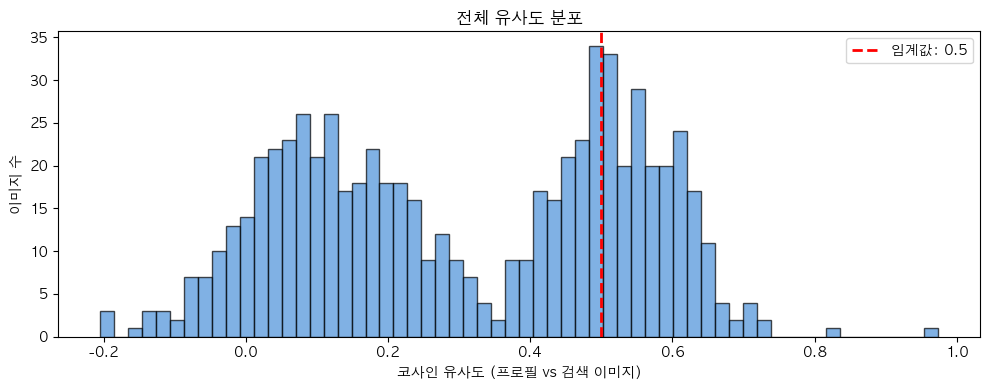

/var/folders/nj/9nc70myx31134b08twnnw67r0000gn/T/ipykernel_49409/3893293601.py:81: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/young/Desktop/Naco/Projects/kbo-lookalike/python/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


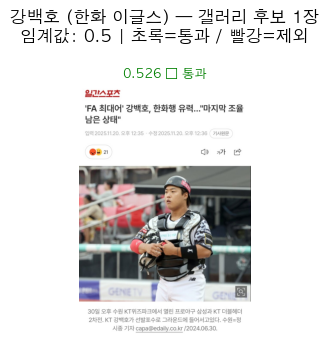

In [12]:
# ============================================================
# 📊 Cell 10: 임계값 튜닝 & 시각화 (로컬 — 재실행 자유)
# ============================================================
# Cell 8의 all_sims 데이터로 유사도 분포를 시각화.
# 임계값 변경 시 어떤 영향이 있는지 확인 가능.
#
# 특정 선수의 검색 이미지를 유사도와 함께 보여줌.
# ============================================================

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# --- 1. 전체 유사도 분포 히스토그램 ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_sims, bins=60, edgecolor="black", alpha=0.7, color="#4A90D9")
ax.axvline(SIMILARITY_THRESHOLD, color="red", linestyle="--", linewidth=2,
           label=f"임계값: {SIMILARITY_THRESHOLD}")
ax.set_xlabel("코사인 유사도 (프로필 vs 검색 이미지)")
ax.set_ylabel("이미지 수")
ax.set_title("전체 유사도 분포")
ax.legend()
plt.tight_layout()
plt.show()

# --- 2. 특정 선수 이미지 시각화 ---
TEST_PLAYER_NAME = "강백호"  # ← 확인하고 싶은 선수 이름

test_pid = next(
    (pid for pid, m in player_meta.items() if m["name"] == TEST_PLAYER_NAME),
    None
)

if test_pid is None:
    print(f"❌ '{TEST_PLAYER_NAME}' 선수를 찾을 수 없습니다")
elif test_pid not in raw_embeddings or not raw_embeddings[test_pid]:
    print(f"❌ '{TEST_PLAYER_NAME}' 선수의 갤러리 이미지가 없습니다")
else:
    meta = player_meta[test_pid]
    ref_emb = profile_embeddings[test_pid]
    entries = raw_embeddings[test_pid]

    # 유사도 계산 & 정렬
    scored = []
    for entry in entries:
        emb = np.array(entry["embedding"], dtype=np.float32)
        sim = cosine_sim(emb, ref_emb)
        img_path = GALLERY_IMG_DIR / entry["file"]
        scored.append((sim, img_path))
    scored.sort(key=lambda x: x[0], reverse=True)

    cols = min(len(scored), 6)
    rows = (len(scored) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3.5 * rows))
    if rows * cols == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()

    for i, (sim, img_path) in enumerate(scored):
        if not img_path.exists():
            axes[i].set_title("파일 없음", fontsize=8)
            axes[i].axis("off")
            continue

        color = "green" if sim >= SIMILARITY_THRESHOLD else "red"
        label = "✅ 통과" if sim >= SIMILARITY_THRESHOLD else "❌ 제외"
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{sim:.3f} {label}", fontsize=9, color=color)
        axes[i].axis("off")

    for j in range(len(scored), len(axes)):
        axes[j].axis("off")

    plt.suptitle(
        f"{meta['name']} ({meta['team']}) — 갤러리 후보 {len(scored)}장\n"
        f"임계값: {SIMILARITY_THRESHOLD} | 초록=통과 / 빨강=제외",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

In [13]:
# ============================================================
# ✅ Cell 11: 최종 요약
# ============================================================

print("=" * 60)
print("🎉 Gallery Expansion 파이프라인 완료!")
print("=" * 60)

files = {
    "기존 임베딩 (변경 없음)": ORIG_EMB_PATH,
    "갤러리 임베딩 (신규)":    GALLERY_EMB_PATH,
    "갤러리 이미지 폴더":       GALLERY_IMG_DIR,
    "중간 파일 (raw)":         RAW_EMB_PATH,
}

print()
for desc, path in files.items():
    if path.exists():
        if path.is_dir():
            cnt = len(list(path.glob("[0-9]*.jpg")))
            print(f"  ✅ {desc}: {cnt}개 파일")
        else:
            mb = path.stat().st_size / (1024 * 1024)
            print(f"  ✅ {desc}: {mb:.2f} MB")
    else:
        print(f"  ❌ {desc}: 없음")

print()
print("📌 다음 단계:")
print("   1. web/public의 symlink를 gallery 임베딩 파일도 가리키도록 추가")
print("   2. web/src/ml/similarity.ts 수정:")
print("      - embeddings 포맷 변경 (단일 → 복수)")
print("      - max similarity로 집계")
print("   3. web/src/types/player.ts PlayerEmbeddings 타입 업데이트")

🎉 Gallery Expansion 파이프라인 완료!

  ✅ 기존 임베딩 (변경 없음): 8.20 MB
  ✅ 갤러리 임베딩 (신규): 10.28 MB
  ✅ 갤러리 이미지 폴더: 15061개 파일
  ✅ 중간 파일 (raw): 3.44 MB

📌 다음 단계:
   1. web/public의 symlink를 gallery 임베딩 파일도 가리키도록 추가
   2. web/src/ml/similarity.ts 수정:
      - embeddings 포맷 변경 (단일 → 복수)
      - max similarity로 집계
   3. web/src/types/player.ts PlayerEmbeddings 타입 업데이트
